<a href="https://colab.research.google.com/github/Anand000007/DSML-Training-Projects/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")
plt.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": 14})


In [9]:
DATA_ROOT = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data"


def fetch_csv(relative_path, **kwargs):
    print(f"Downloading {relative_path} ...")
    return pd.read_csv(f"{DATA_ROOT}/{relative_path}", **kwargs)


df_vacc = fetch_csv("vaccinations/country_data/India.csv")

cols_needed = ["location", "date", "new_cases", "total_cases"]
df_cases = (
    fetch_csv("owid-covid-data.csv", usecols=cols_needed)
    .query("location == 'India'")
    .reset_index(drop=True)
)

print(f"Vaccinations: {df_vacc.shape[0]} rows | Cases: {df_cases.shape[0]} rows")


Vaccinations: 1250 rows | Cases: 1682 rows


In [10]:
def to_datetime_safe(df, col="date"):
    df[col] = pd.to_datetime(df[col])
    return df


df_vacc = to_datetime_safe(df_vacc)
df_cases = to_datetime_safe(df_cases)

if "people_fully_vaccinated" not in df_vacc.columns:
    df_vacc["people_fully_vaccinated"] = np.nan

df_vacc["total_vaccinations"] = df_vacc["total_vaccinations"].ffill().fillna(0)
df_vacc["people_fully_vaccinated"] = df_vacc["people_fully_vaccinated"].ffill().fillna(0)
df_vacc["daily_vaccinations"] = df_vacc["total_vaccinations"].diff().clip(lower=0).fillna(0)

df_cases["new_cases"] = df_cases["new_cases"].clip(lower=0).fillna(0)
df_cases["total_cases"] = df_cases["total_cases"].ffill().fillna(0)

ROLL_WINDOW = 7
df_cases["new_cases_7d_avg"] = df_cases["new_cases"].rolling(ROLL_WINDOW, min_periods=1).mean()
df_vacc["daily_vacc_7d_avg"] = df_vacc["daily_vaccinations"].rolling(ROLL_WINDOW, min_periods=1).mean()

df_merged = (
    df_cases.merge(df_vacc, on="date", how="outer")
    .sort_values("date")
    .assign(location="India")
    .reset_index(drop=True)
)

df_merged.tail(3)


,location_x,date,total_cases,new_cases,new_cases_7d_avg,location_y,vaccine,source_url,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,daily_vaccinations,daily_vacc_7d_avg,location
1679,India,2024-08-10,45041748.0,0.0,44.714286,India,"Corbevax, Covaxin, Novavax, Oxford/AstraZeneca...",https://dashboard.cowin.gov.in/,2.206868e+09,1.027439e+09,951990545.0,227438523.0,16.0,8.571429,India
1680,India,2024-08-11,45041748.0,0.0,0.000000,India,"Corbevax, Covaxin, Novavax, Oxford/AstraZeneca...",https://dashboard.cowin.gov.in/,2.206868e+09,1.027439e+09,951990547.0,227438524.0,7.0,7.857143,India
1681,India,2024-08-12,45041748.0,0.0,0.000000,India,"Corbevax, Covaxin, Novavax, Oxford/AstraZeneca...",https://dashboard.cowin.gov.in/,2.206868e+09,1.027439e+09,951990552.0,NaN,7.0,7.857143,India


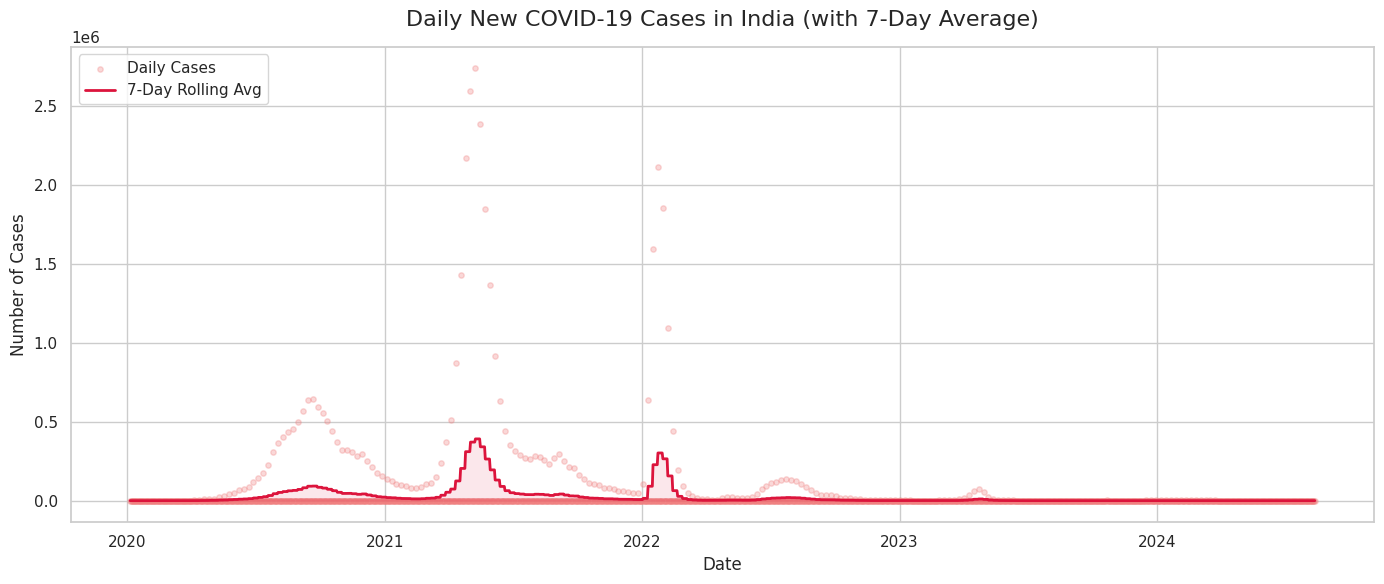

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(df_cases["date"], df_cases["new_cases"], color="lightcoral", alpha=0.3, s=15, label="Daily Cases")
ax.plot(df_cases["date"], df_cases["new_cases_7d_avg"], color="crimson", linewidth=2, label="7-Day Rolling Avg")
ax.fill_between(df_cases["date"], df_cases["new_cases_7d_avg"], color="crimson", alpha=0.1)

ax.set_title("Daily New COVID-19 Cases in India (with 7-Day Average)", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Number of Cases", fontsize=12)
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()


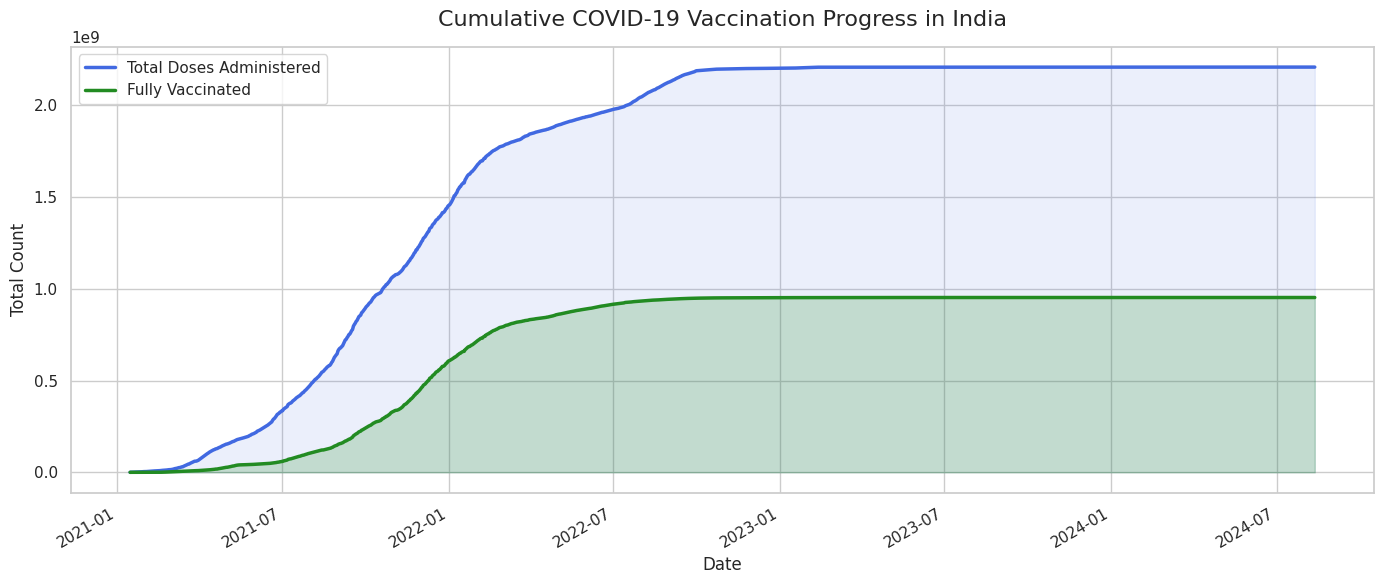

In [12]:
ax = df_vacc.plot(
    x="date",
    y=["total_vaccinations", "people_fully_vaccinated"],
    figsize=(14, 6),
    linewidth=2.5,
    color=["royalblue", "forestgreen"],
)

ax.fill_between(df_vacc["date"], df_vacc["total_vaccinations"], color="royalblue", alpha=0.1)
ax.fill_between(df_vacc["date"], df_vacc["people_fully_vaccinated"], color="forestgreen", alpha=0.2)

ax.set_title("Cumulative COVID-19 Vaccination Progress in India", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Total Count", fontsize=12)
ax.legend(["Total Doses Administered", "Fully Vaccinated"], loc="upper left")

plt.tight_layout()
plt.show()


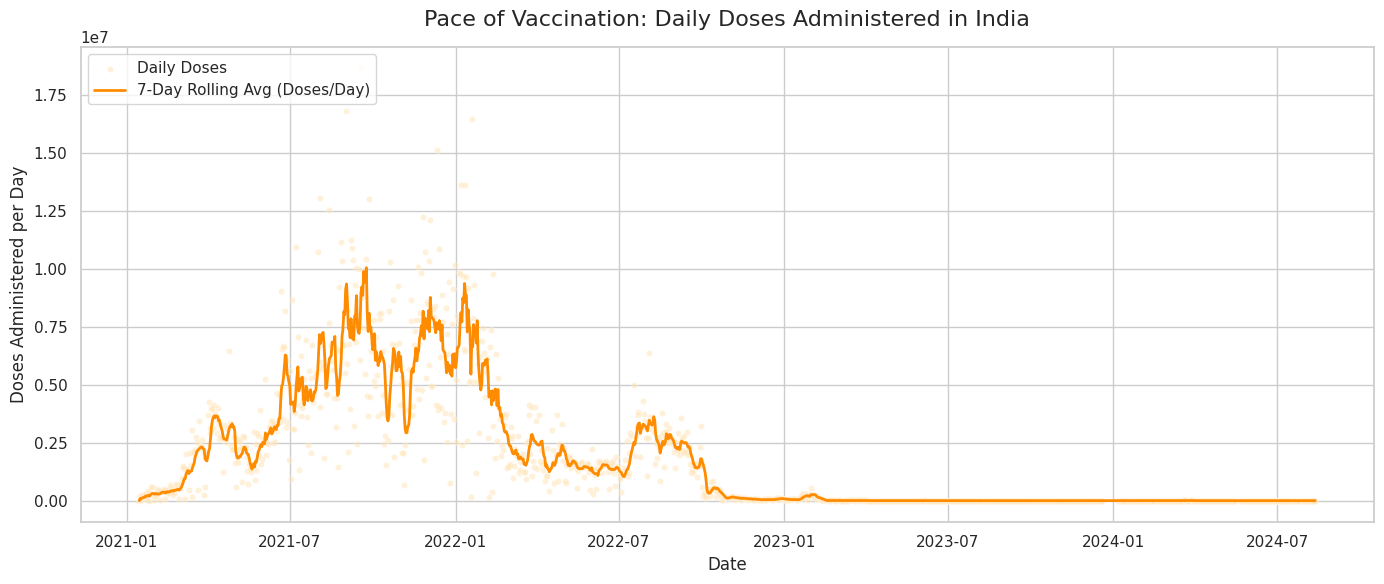

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.scatterplot(data=df_vacc, x="date", y="daily_vaccinations", color="moccasin", alpha=0.5, s=20,
                 label="Daily Doses", ax=ax)
sns.lineplot(data=df_vacc, x="date", y="daily_vacc_7d_avg", color="darkorange", linewidth=2,
             label="7-Day Rolling Avg (Doses/Day)", ax=ax)

ax.set_title("Pace of Vaccination: Daily Doses Administered in India", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Doses Administered per Day", fontsize=12)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


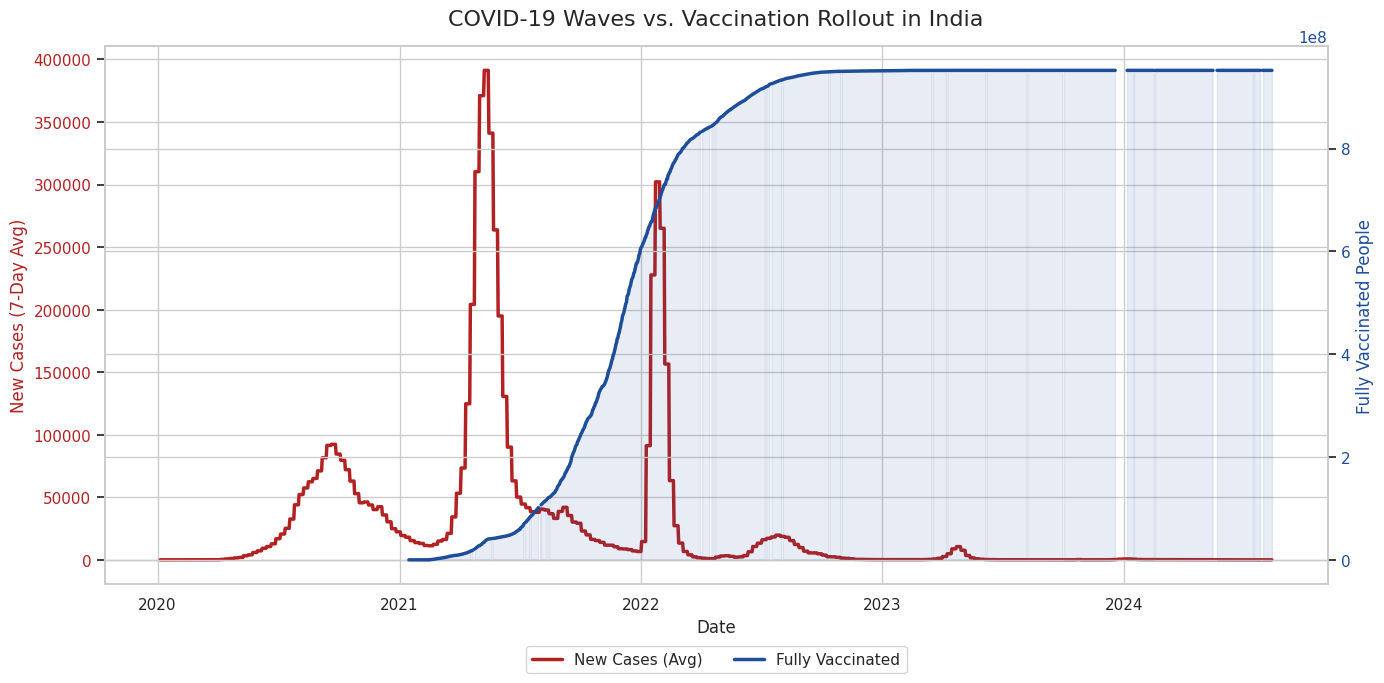

In [14]:
fig, ax_cases = plt.subplots(figsize=(14, 7))

case_color, vacc_color = "#b22222", "#1f4e99"

ax_cases.plot(df_merged["date"], df_merged["new_cases_7d_avg"], color=case_color, linewidth=2.5,
              label="New Cases (Avg)")
ax_cases.set_xlabel("Date", fontsize=12)
ax_cases.set_ylabel("New Cases (7-Day Avg)", color=case_color, fontsize=12)
ax_cases.tick_params(axis="y", labelcolor=case_color)

ax_vacc = ax_cases.twinx()
ax_vacc.plot(df_merged["date"], df_merged["people_fully_vaccinated"], color=vacc_color, linewidth=2.5,
             label="Fully Vaccinated")
ax_vacc.fill_between(df_merged["date"], df_merged["people_fully_vaccinated"], color=vacc_color, alpha=0.1)
ax_vacc.set_ylabel("Fully Vaccinated People", color=vacc_color, fontsize=12)
ax_vacc.tick_params(axis="y", labelcolor=vacc_color)

handles = ax_cases.get_lines() + ax_vacc.get_lines()
labels = [h.get_label() for h in handles]
ax_cases.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.title("COVID-19 Waves vs. Vaccination Rollout in India", fontsize=16, pad=15)
plt.tight_layout()
plt.show()
